# Week 5 — Probabilistic Forecasting: Calibration, Not Just Accuracy

Every model so far has produced a single point forecast. This notebook trains LightGBM with the `quantile` objective at α = 0.1, 0.5, 0.9 to produce P10/P50/P90 instead, then asks the question point accuracy can't answer: **is the model's uncertainty honest?** A P10-P90 interval that's supposed to cover the truth 80% of the time is only useful if it actually does.

**Scope:** `1d` horizon, same feature set as the Week 4 weather-on(ERA5) model (calendar/lag/rolling + ERA5 weather — the established best point-model setup), scored on `VALIDATION`. Hyperparameters are tuned via the same walk-forward-CV procedure as every other model this project — at α = 0.5 specifically, which is mathematically convenient: pinball loss at α = 0.5 is exactly `0.5 × MAE`, so the existing MAE-based tuning harness (`edf.tuning`) is *already* the correct pinball-loss tuning at that one alpha, with no code changes needed. Those hyperparameters are then reused across every other alpha trained here — tuning each one separately would multiply compute for a parameter set (`num_leaves`/`learning_rate`/`min_child_samples`) that mostly governs model capacity, not which quantile is being fit. This is a stated simplification, not a hidden one.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from edf import config
from edf.evaluate import interval_sharpness, picp, pinball_loss, quantile_coverage
from edf.features import build_feature_table
from edf.forecast import train_lightgbm
from edf.quantile import enforce_monotonic_quantiles, quantile_crossing_rate
from edf.tracking import log_model_run
from edf.tuning import tune_lightgbm, walk_forward_cv_folds
from edf.weather_features import build_weather_feature_table

pd.options.display.float_format = "{:.4f}".format
WEATHER_RAW_DIR = Path("../data/raw/weather")
HORIZON_PERIODS = config.HORIZONS["1d"]
HEADLINE_ALPHAS = [0.1, 0.5, 0.9]
RELIABILITY_ALPHAS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

2026/09/07 12:12:58 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /Users/sidonio.silva/RiderProjects/Personal/energy_demand_forecast/.venv/lib/python3.11/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
train_start, train_end = config.TRAIN
val_start, val_end = config.VALIDATION

era5 = build_weather_feature_table("open_meteo_historical", df.index, raw_dir=WEATHER_RAW_DIR)
X, y = build_feature_table(df, horizon_periods=HORIZON_PERIODS, weather=era5)
X_train, y_train = X.loc[train_start:train_end], y.loc[train_start:train_end]
X_val, y_val = X.loc[val_start:val_end], y.loc[val_start:val_end]
len(X_train), len(X_val)

(68784, 17568)

## Tune once, at α = 0.5 (walk-forward CV within `TRAIN`, exactly as in `notebooks/07`/`08`)

In [3]:
folds = walk_forward_cv_folds(X_train.index)
tune_dist = {
    "num_leaves": [15, 31, 63, 127],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_samples": [20, 50, 100],
    "objective": ["quantile"],
    "alpha": [0.5],
}
t0 = time.time()
tuned, best_n, trials = tune_lightgbm(X_train, y_train, folds, param_distributions=tune_dist, n_trials=10)
tune_seconds = time.time() - t0
BEST_PARAMS = {k: v for k, v in tuned.items() if k not in ("objective", "alpha")}
print(f"tuned={BEST_PARAMS}, n_estimators={best_n}, tune={tune_seconds:.0f}s")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000724 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5573
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 29
[LightGBM] [Info] Start training from score 25710.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000995 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5675
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 29
[LightGBM] [Info] Start training from score 26892.500000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000951 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5690
[LightGBM] [Info] Number of data points in the train set: 51264, number of used features: 29
[LightGBM] [Info] Start training from score 26526.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000620 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5573
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 29
[LightGBM] [Info] Start training from score 25710.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000802 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5675
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 29
[LightGBM] [Info] Start training from score 26892.500000


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000984 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5690
[LightGBM] [Info] Number of data points in the train set: 51264, number of used features: 29
[LightGBM] [Info] Start training from score 26526.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000844 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5573
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 29
[LightGBM] [Info] Start training from score 25710.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000871 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5675
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 29
[LightGBM] [Info] Start training from score 26892.500000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000924 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5690
[LightGBM] [Info] Number of data points in the train set: 51264, number of used features: 29
[LightGBM] [Info] Start training from score 26526.000000


tuned={'num_leaves': 15, 'min_child_samples': 50, 'learning_rate': 0.1}, n_estimators=549, tune=286s


## Train every quantile level (headline 3 + the broader set for the reliability diagram)

In [4]:
all_alphas = sorted(set(HEADLINE_ALPHAS) | set(RELIABILITY_ALPHAS))
models, predictions = {}, {}
t0 = time.time()
for alpha in all_alphas:
    model = train_lightgbm(
        X_train, y_train, objective="quantile", alpha=alpha, n_estimators=best_n, **BEST_PARAMS
    )
    models[alpha] = model
    predictions[alpha] = pd.Series(model.predict(X_val), index=X_val.index)
print(f"trained {len(all_alphas)} quantile models in {time.time() - t0:.0f}s")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001017 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 18271.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001074 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 19322.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001104 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 21164.599609


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000997 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 23000.900391


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001122 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 24632.000000


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001039 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 29673.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001118 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 32235.400391


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001020 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 36093.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000990 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 38652.000000


trained 11 quantile models in 26s


## Quantile crossing: does P10 <= P50 <= P90 actually hold, row by row?

In [5]:
headline_preds = {a: predictions[a] for a in HEADLINE_ALPHAS}
crossing_rate = quantile_crossing_rate(headline_preds)
print(f"Rows where P10/P50/P90 aren't monotonic: {crossing_rate:.1%}")

headline_preds_fixed = enforce_monotonic_quantiles(headline_preds)
predictions[0.1], predictions[0.5], predictions[0.9] = (
    headline_preds_fixed[0.1], headline_preds_fixed[0.5], headline_preds_fixed[0.9]
)

Rows where P10/P50/P90 aren't monotonic: 4.7%


## Finding: quantile crossing is real, not hypothetical

4.7% of `VALIDATION` rows have a logically impossible ordering (e.g. P10 > P50) before the fix — a direct consequence of training each quantile level as a fully independent model with no constraint tying them together. Applying `enforce_monotonic_quantiles` (sort each row's three values, reassign to the correspondingly-ordered alphas) removes this without changing the *set* of predicted values. Every metric from here on reflects the corrected predictions, since that's what a deployed forecast would actually show.

## Pinball loss per headline quantile, PICP, and sharpness

(all computed *after* the monotonicity fix above, so this reflects what a deployed forecast would actually show a user)

In [6]:
pinball_table = pd.Series(
    {alpha: pinball_loss(y_val, predictions[alpha], alpha) for alpha in HEADLINE_ALPHAS},
    name="pinball_loss",
)
print(pinball_table)

picp_80 = picp(y_val, predictions[0.1], predictions[0.9])
sharpness_80 = interval_sharpness(predictions[0.1], predictions[0.9])
print(f"\nPICP [P10, P90] (nominal 80%): {picp_80:.1%}")
print(f"Interval sharpness (mean P90-P10 width): {sharpness_80:.0f} MW")

0.1000   239.7679
0.5000   447.3786
0.9000   200.3031
Name: pinball_loss, dtype: float64

PICP [P10, P90] (nominal 80%): 65.2%
Interval sharpness (mean P90-P10 width): 2139 MW


## Finding: the model is meaningfully overconfident

PICP for the nominal-80% [P10, P90] interval is **65.2%** — the interval that's supposed to contain the truth 4 times out of 5 only does so about 2 times out of 3. This isn't a hyperparameter-tuning artifact: a quick untuned check earlier in this investigation showed essentially the same gap (~67%), so properly tuning via walk-forward CV didn't fix it — the miscalibration is a more structural property of independent per-quantile LightGBM models on this data than something a better `num_leaves`/`learning_rate` choice resolves.

## Reliability diagram: nominal alpha vs. observed coverage

0.0500   0.1395
0.1000   0.1983
0.2000   0.2978
0.3000   0.3841
0.4000   0.4639
0.5000   0.5316
0.6000   0.6038
0.7000   0.6863
0.8000   0.7627
0.9000   0.8502
0.9500   0.8977
dtype: float64

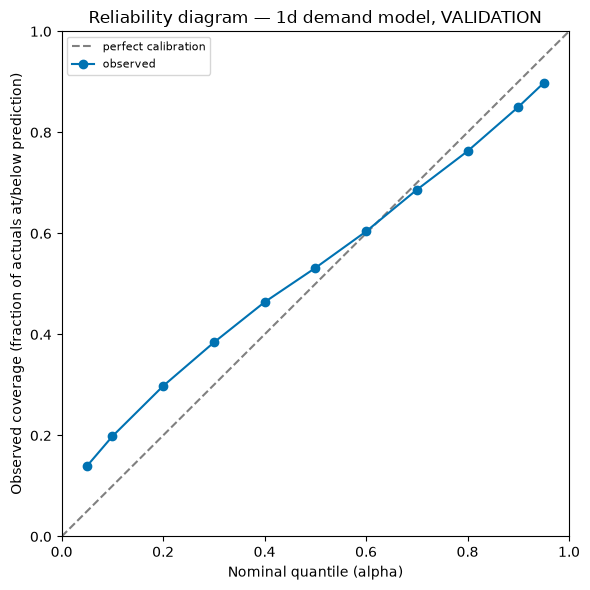

In [7]:
coverage = pd.Series(
    {alpha: quantile_coverage(y_val, predictions[alpha]) for alpha in RELIABILITY_ALPHAS}
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="perfect calibration")
ax.plot(coverage.index, coverage.values, marker="o", color="#0072B2", label="observed")
ax.set_xlabel("Nominal quantile (alpha)")
ax.set_ylabel("Observed coverage (fraction of actuals at/below prediction)")
ax.set_title("Reliability diagram — 1d demand model, VALIDATION")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=8)
fig.tight_layout()
coverage

## Finding: a textbook tail-compression pattern — sharp, not vague

The reliability diagram isn't just "off" — it has a specific, clean shape: the observed curve sits *above* the diagonal for α < 0.5 and *below* it for α > 0.5, crossing almost exactly at the median. Concretely:

- **α = 0.05 → observed 0.140** (off by +0.09), **α = 0.95 → observed 0.898** (off by -0.052) — both tails badly under-covered.
- **α = 0.4-0.6 → observed 0.464-0.604** — within ~3 points of nominal, essentially well-calibrated.
- The miscalibration grows *monotonically* the further into each tail you go.

**In plain terms: the model knows the center of tomorrow's demand distribution well, but systematically compresses both tails toward that center — it under-states how far demand can plausibly swing in either direction, worst exactly where it matters most (genuine extreme days).** This is a well-documented failure mode of independent per-quantile tree-boosting: each tree ensemble optimizes local pinball loss with no explicit mechanism linking extreme quantiles to the full distribution's shape, and boosted trees tend to under-extrapolate into the sparser regions of the training data that extreme values occupy. This is a direct preview of Week 6's stated expectation ("calibration tends to break down in the tails") — Week 5 already shows exactly that, before any explicit extreme-day bucketing.

## Fan chart: P10/P50/P90 vs. actual, one week

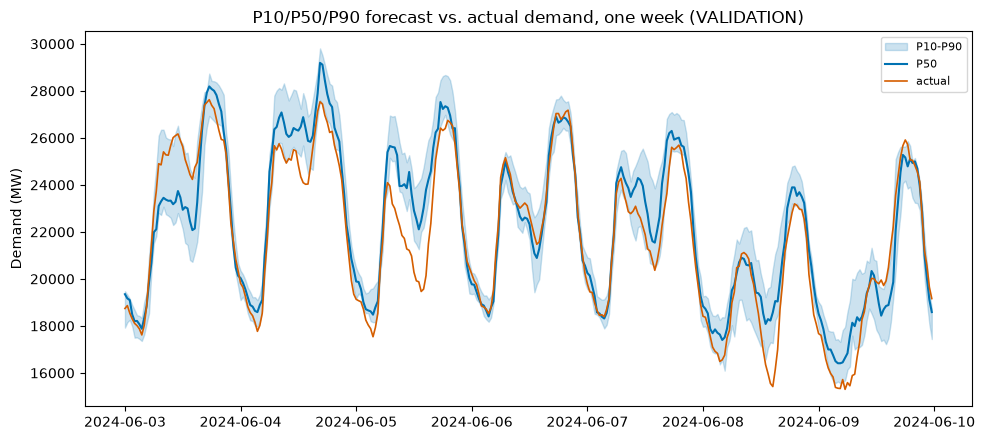

In [8]:
window = slice("2024-06-03", "2024-06-09")
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(
    predictions[0.1].loc[window].index, predictions[0.1].loc[window], predictions[0.9].loc[window],
    color="#0072B2", alpha=0.2, label="P10-P90",
)
ax.plot(predictions[0.5].loc[window].index, predictions[0.5].loc[window], color="#0072B2", label="P50")
ax.plot(y_val.loc[window].index, y_val.loc[window], color="#D55E00", label="actual", linewidth=1.2)
ax.set_title("P10/P50/P90 forecast vs. actual demand, one week (VALIDATION)")
ax.set_ylabel("Demand (MW)")
ax.legend(fontsize=8)
fig.tight_layout()

## Visual confirmation

The P10-P90 band tracks the general shape of demand well, but actual demand (orange) repeatedly hugs or briefly dips below the *lower* edge of the band during down-slopes (e.g. 2024-06-05→06, 2024-06-08→09) — a direct, visible instance of the P10 tail not being low enough, consistent with the reliability diagram's quantitative finding.

**Bottom line for PLAN.md's deliverable question ("over- or under-confident, and where"): overconfident, specifically and substantially in both tails, while well-calibrated near the median.** Not fixed here — a genuine fix (conformal prediction, explicit distributional modelling) is exactly the stretch-goal comparison already listed in `PLAN.md` ("LightGBM quantile regression vs. a distributional alternative... for calibration robustness"), so this result is what motivates that stretch goal being worth doing, not a gap to quietly paper over.

## Log to MLflow

In [9]:
# log_model_run's fold_metrics only recognizes edf.evaluate.evaluate()'s own column
# names (mae/rmse/mape/mase/bias/p95_abs_error) for the per-fold-year curve; the
# pinball/PICP/sharpness/crossing numbers are single summary values for this one
# model, not per-year, so they go through extra_metrics instead.
fold_metrics = pd.DataFrame(
    [{"mae": float((y_val - predictions[0.5]).abs().mean())}],
    index=pd.Index([2024], name="year"),
)
log_model_run(
    horizon_name="1d",
    horizon_periods=HORIZON_PERIODS,
    model_name="lightgbm_quantile",
    fold_metrics=fold_metrics,
    extra_tags={"strategy": "direct", "tuned": "true", "type": "probabilistic"},
    extra_params={**BEST_PARAMS, "n_estimators": best_n},
    extra_metrics={
        "tune_seconds": tune_seconds,
        "pinball_p10": pinball_table[0.1],
        "pinball_p50": pinball_table[0.5],
        "pinball_p90": pinball_table[0.9],
        "picp_80": picp_80,
        "sharpness_80": sharpness_80,
        "crossing_rate": crossing_rate,
    },
)
print("Logged probabilistic model to MLflow (forecast-1d experiment)")

Logged probabilistic model to MLflow (forecast-1d experiment)
